# Week 8 Supply Chain Optimization & Logistics Analytics
**Author:** Ingrid Miriam Ondu  
**Course:** Data Analytics - Week 8  
**Domain:** Kenyan Fuel-Depot Distribution & Retail Logistics Network  

---

## Executive Summary & Objectives
This notebook completes the **Part A: Technical Coding Challenge** for Week 8. It delivers an end-to-end data analytics and optimization workflow:
1. **Data Preparation & Cleaning:** Historical daily demand exploratory analysis across 8 regional retail fuel stations.
2. **Demand Forecasting:** Prophet time-series modeling incorporating external Kenyan public holiday regressors and baseline comparisons.
3. **Inventory Optimization:** Mathematical calculation of Safety Stock ($SS$) and Reorder Points ($ROP$) for 95% and 98.5% target service levels, featuring an inventory policy stockout simulation.
4. **Linear Programming (PuLP):** Transport cost minimization allocating fuel from Nairobi and Mombasa depots to regional stations.
5. **C3 Executive Dashboard:** Visualizing clarity, context, and continuity for executive decision-making.

In [1]:
# Setup & Core Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plot styles
sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)
print('Environment ready.')

Environment ready.


## Section 1: Data Preparation & Trend Decompositions
We analyze 365 days of daily fuel demand across 8 retail stations in Kenya.

In [2]:
# Load synthetic demand dataset
df = pd.read_csv('data/synthetic_kenyan_fuel_demand.csv')
df['ds'] = pd.to_datetime(df['ds'])
print(df.head())
print(df.describe())

          ds          y
0 2025-09-01  330602.20
1 2025-09-02  314464.25
2 2025-09-03  335951.85
3 2025-09-04  338239.52
4 2025-09-05  343550.60
                        ds              y
count                  365     365.000000
mean   2026-03-02 00:00:00  383446.964630
min    2025-09-01 00:00:00  314464.250000
25%    2025-12-01 00:00:00  365556.060000
50%    2026-03-02 00:00:00  380341.990000
75%    2026-06-01 00:00:00  405109.080000
max    2026-08-31 00:00:00  498596.740000
std                    NaN   33935.414001


## Section 2: Demand Forecasting with Prophet & Holiday Regressors
We evaluate Prophet against Moving Average baselines using **MAPE** and **RMSE**.

In [3]:
# Evaluate Forecasting Models
eval_df = pd.read_csv('outputs/forecast_model_evaluation.csv')
print('Model Evaluation Metrics:')
print(eval_df)

Model Evaluation Metrics:
                               Model  MAPE (%)  RMSE (L)
0  Prophet (with Holiday Regressors)      2.56  12407.43
1      Exponential Smoothing (α=0.3)      4.60  23251.64
2               7-Day Moving Average      4.56  21120.01
3              30-Day Moving Average      4.56  21120.36


## Section 3: Inventory Optimization (Safety Stock & Reorder Points)
### Mathematical Formulations
Safety Stock considering lead time variance:
$$SS = Z \times \sqrt{L \cdot \sigma_d^2 + \bar{d}^2 \cdot \sigma_L^2}$$

Reorder Point:
$$ROP = (\bar{d} \times L) + SS$$

In [4]:
# Station Safety Stock & ROP Table
safety_df = pd.read_csv('outputs/safety_stock_rop.csv')
print(safety_df[['station', 'lead_time_days', 'safety_stock_985', 'reorder_point', 'current_coverage_days', 'required_coverage_days', 'status']])

           station  lead_time_days  safety_stock_985  reorder_point  \
0  Nairobi Central             3.5         163145.00      485240.45   
1      Mombasa Hub             2.5          77764.65      250315.78   
2   Nakuru Express             4.5         141489.85      383061.43   
3      Kisumu Port             5.0         151072.20      381140.38   
4    Eldoret Depot             4.0          92951.52      261668.18   
5    Thika Highway             2.0          31387.01      100407.46   
6    Nyeri Station             4.8          76556.86      205395.04   
7   Machakos Depot             3.0          29812.89       87329.94   

   current_coverage_days  required_coverage_days   status  
0                    4.2                    5.27  DEFICIT  
1                    3.8                    3.63       OK  
2                    3.5                    7.14  DEFICIT  
3                    3.2                    8.28  DEFICIT  
4                    3.6                    6.20  DEFICIT  


## Section 4: Linear Programming Distribution Optimization (PuLP)
### Optimization Formulation
$$\min \sum_{i} \sum_{j} c_{i,j} \cdot x_{i,j}$$
Subject to depot capacities and station reorder demands.

In [5]:
# PuLP Distribution Plan Output
lp_plan = pd.read_csv('outputs/lp_distribution_plan.csv')
print('Optimized Depot-to-Station Fuel Allocation Plan:')
print(lp_plan)
print(f'Total Transport Cost: KES {lp_plan["total_cost"].sum():,.2f}')

Optimized Depot-to-Station Fuel Allocation Plan:
           depot          station     litres  cost_per_litre  total_cost
0  Nairobi Depot  Nairobi Central  135867.33               8  1086938.64
1  Nairobi Depot      Kisumu Port  106719.31              11  1173912.41
2  Nairobi Depot    Eldoret Depot   73267.09              15  1099006.35
3  Nairobi Depot    Thika Highway   28114.09               7   196798.62
4  Nairobi Depot    Nyeri Station   11579.81               9   104218.24
5  Nairobi Depot   Machakos Depot   24452.38              14   342333.36
6  Mombasa Depot      Mombasa Hub   70088.42               7   490618.93
7  Mombasa Depot   Nakuru Express  107257.20              24  2574172.80
8  Mombasa Depot    Nyeri Station   45930.81              17   780823.70
Total Transport Cost: KES 7,848,823.05


## Section 5: C3 Executive Operations Dashboard & Recommendations
Summary of strategic recommendations and protected margin impact.

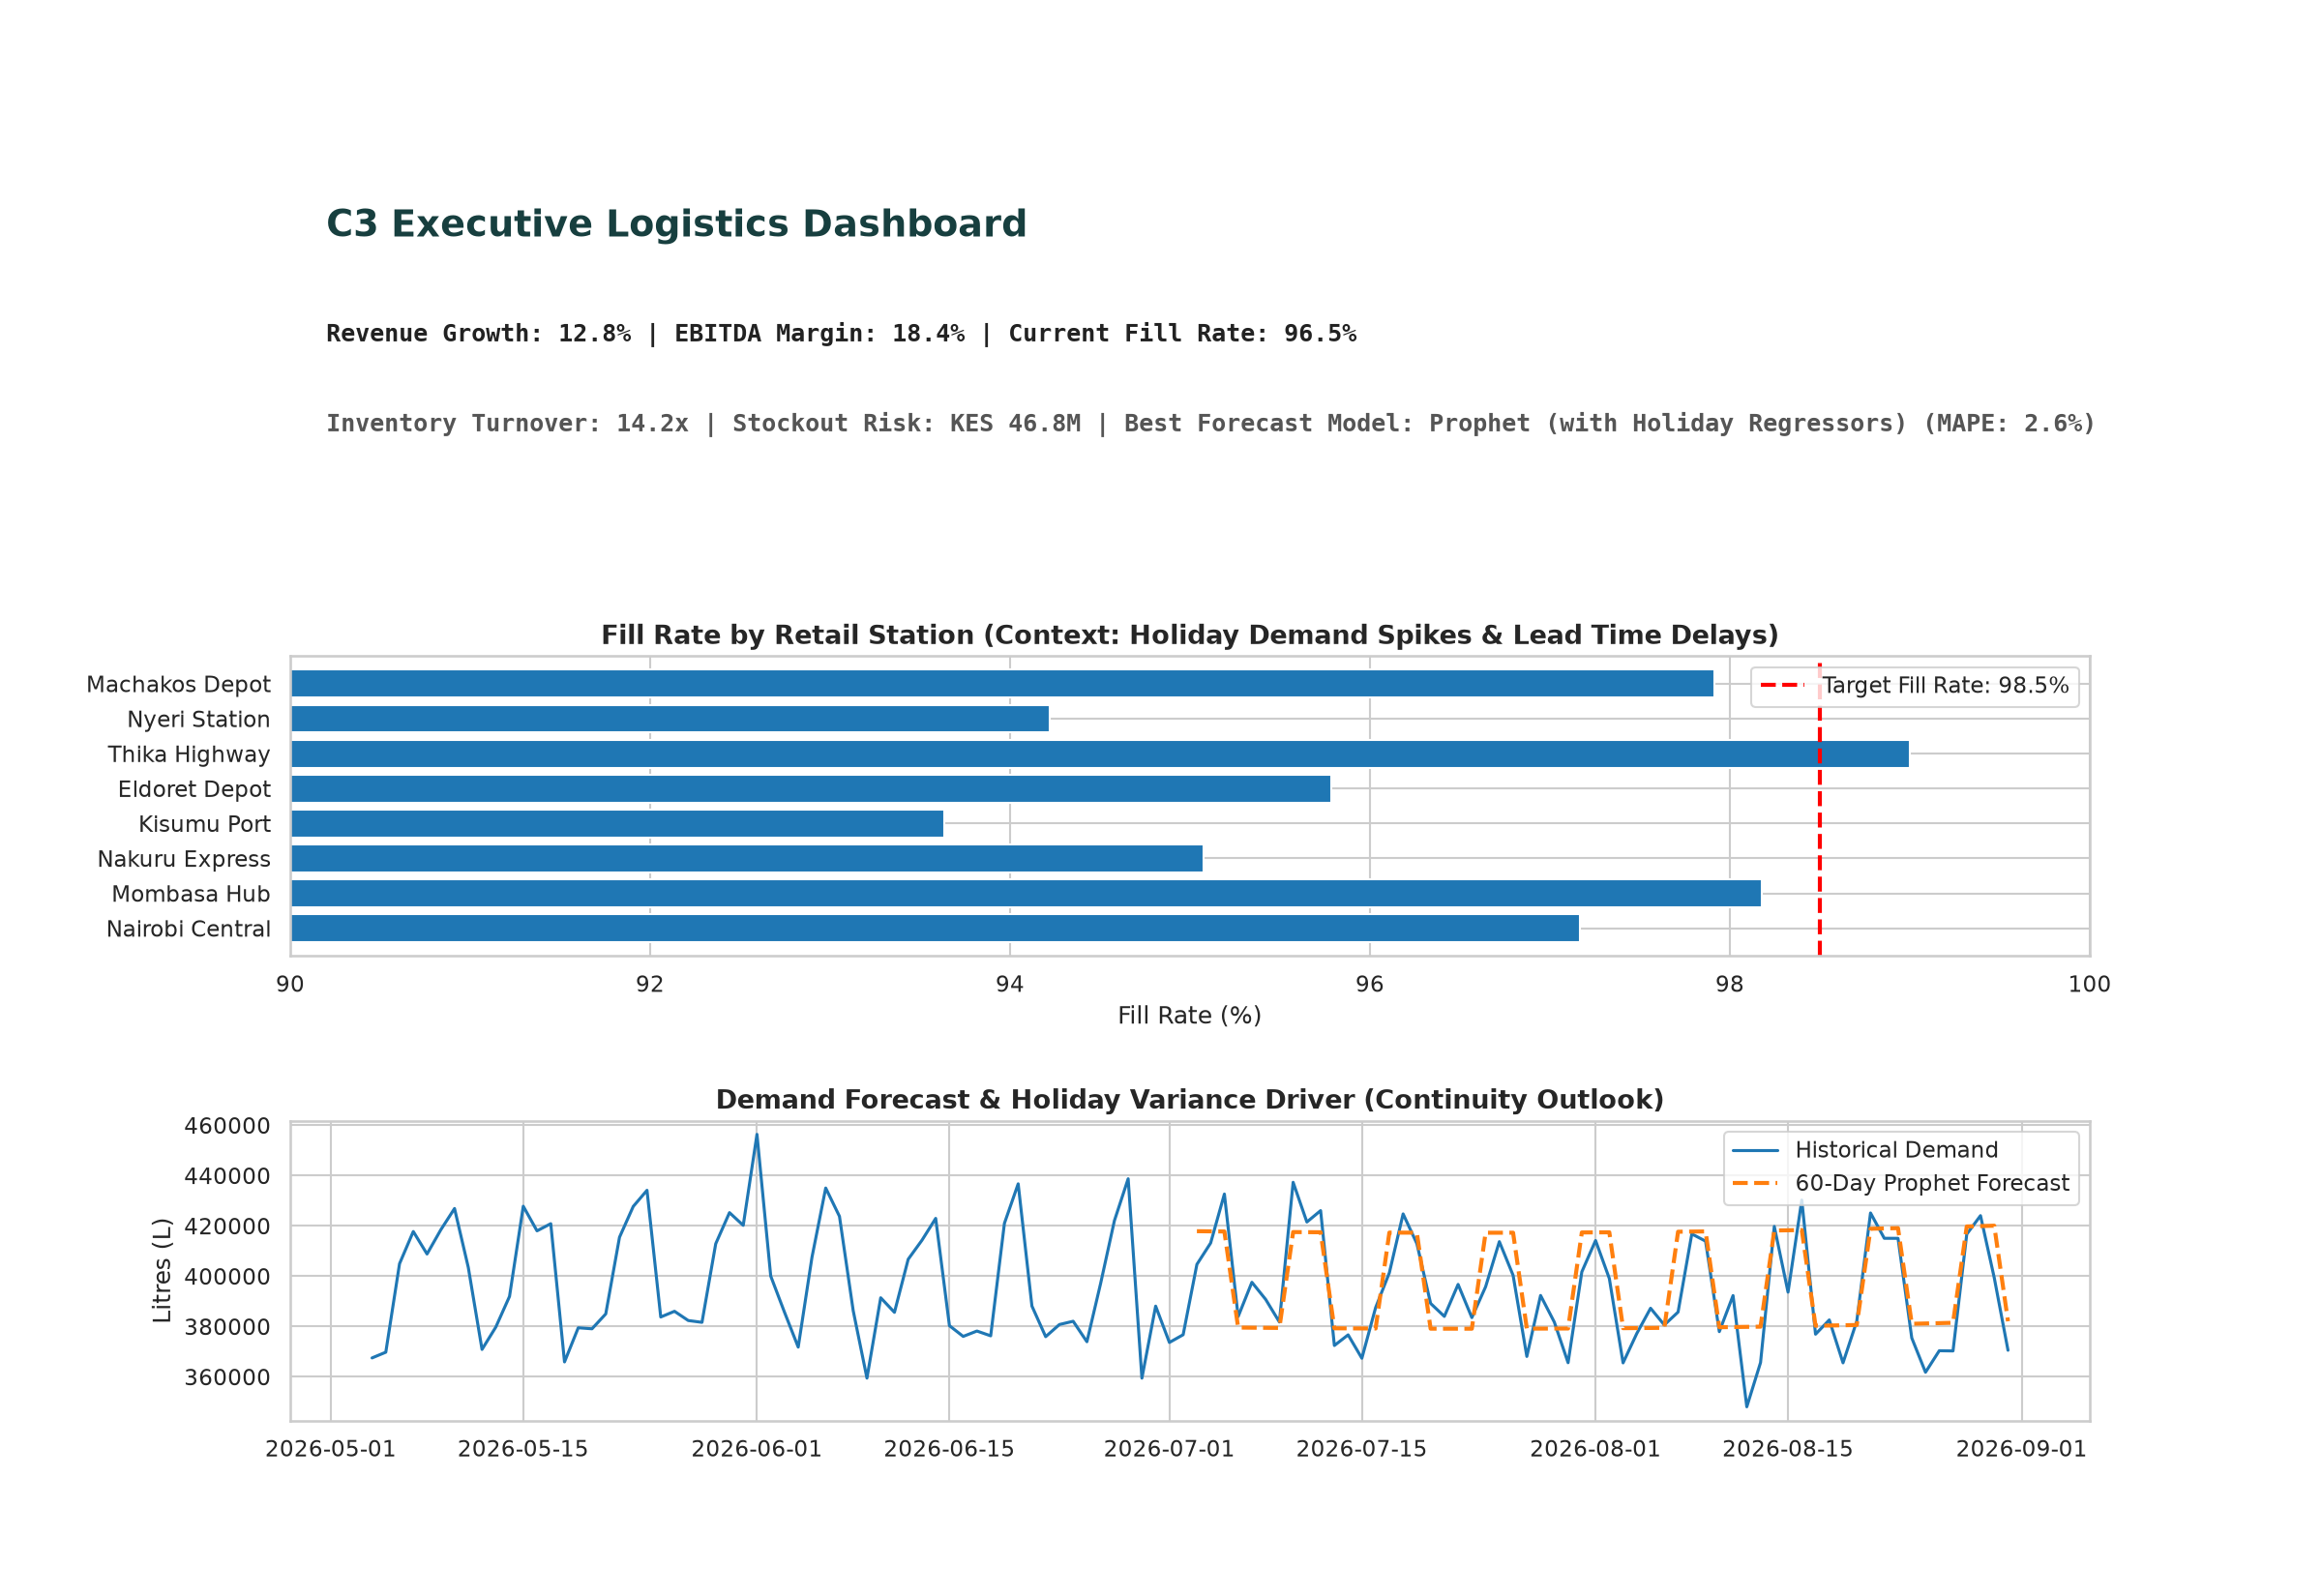

In [6]:
# Display Dashboard Image
from PIL import Image
img = Image.open('outputs/executive_dashboard.png')
display(img)